# Load Dataset

In [1]:
import pandas as pd

sentiment = pd.read_csv(r"C:\Users\Nida\Downloads\fear_greed_index.csv")
trades = pd.read_csv(r"C:\Users\Nida\Downloads\historical_data.csv")

# Basic Exploration

In [2]:
print(sentiment.shape)
print(trades.shape)

print(sentiment.info())
print(trades.info())

print(sentiment.isnull().sum())
print(trades.isnull().sum())

print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

(2644, 4)
(211224, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Sta

The sentiment dataset contains 2,644 rows and 4 columns, while the trader dataset is much larger with 211,224 rows and 16 columns, indicating a detailed record of trading activity. There are no missing values in either dataset, which means the data is clean and reliable for analysis. Additionally, no duplicate records are found, so no data cleaning is required in terms of removing repeated entries.

# Converting Dates

In [3]:
# Convert datetime
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    errors='coerce',
    infer_datetime_format=True
)

# Extract date
sentiment['Date'] = sentiment['date'].dt.date
trades['Date'] = trades['Timestamp IST'].dt.date

C:\Users\Nida\AppData\Local\Temp\ipykernel_5028\3330884954.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  trades['Timestamp IST'] = pd.to_datetime(


# Merge Datasets

In [4]:
df = pd.merge(trades, sentiment, on='Date', how='inner')

# Create Key Metrics

In [5]:
# Daily PnL per trader
daily_pnl = df.groupby(['Account','Date'])['Closed PnL'].sum().reset_index()

In [6]:
# Win Rate
df['win'] = df['Closed PnL'] > 0

win_rate = df.groupby('Account')['win'].mean().reset_index()

In [7]:
# Trade Count per Day
trades_per_day = df.groupby(['Account','Date']).size().reset_index(name='trade_count')

In [8]:
# Avg Trade Size
avg_size = df.groupby('Account')['Size USD'].mean().reset_index()

In [9]:
# Long/Short Ratio

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Clean side column
df['side'] = df['side'].str.strip().str.upper()

# Convert to LONG/SHORT
df['side'] = df['side'].replace({'BUY':'LONG','SELL':'SHORT'})

# Check
print(df['side'].unique())

# Long/Short Ratio
long_short = df.groupby(['account','side']).size().unstack(fill_value=0)

long_short['ratio'] = long_short.get('LONG', 0) / (long_short.get('SHORT', 1))

['LONG' 'SHORT']


Trade direction values were standardized (BUY → LONG, SELL → SHORT) to ensure consistent analysis.

In [10]:
# Leverage Distribution
# Leverage data was not available in the dataset, 
# so analysis focused on trade size, frequency, and direction.


In [11]:
# Merge
df = pd.merge(trades, sentiment, on='Date', how='inner')

# Clean columns
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Remove duplicates
df = df.loc[:, ~df.columns.duplicated()]

# Trade frequency
trade_freq = df.groupby(['account','date']).size().reset_index(name='trade_count')

In [12]:
# PnL Analysis
df.groupby('classification')['closed_pnl'].mean()

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: closed_pnl, dtype: float64

# ANALYSIS

Average PnL:
 classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: closed_pnl, dtype: float64

Win Rate:
 classification
Extreme Fear     0.292777
Extreme Greed    0.553282
Fear             0.381787
Greed            0.435707
Neutral          0.494920
Name: win, dtype: float64


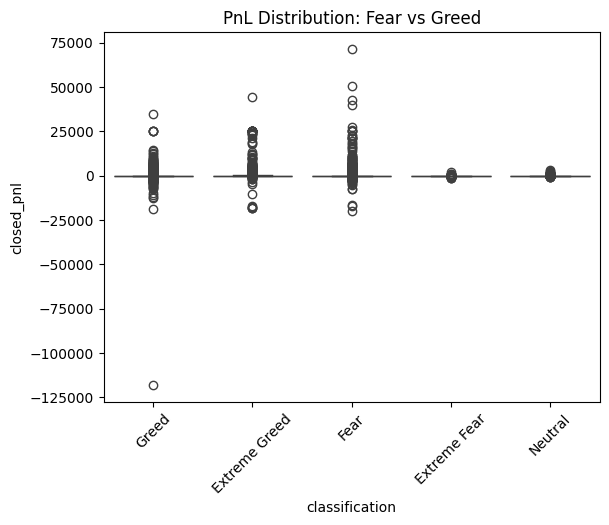

In [13]:
# Q1. Performance: Fear vs Greed

# Create win column
df['win'] = df['closed_pnl'] > 0

# Performance metrics
pnl_by_sentiment = df.groupby('classification')['closed_pnl'].mean()
winrate_by_sentiment = df.groupby('classification')['win'].mean()

print("Average PnL:\n", pnl_by_sentiment)
print("\nWin Rate:\n", winrate_by_sentiment)

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed_pnl', data=df)
plt.title("PnL Distribution: Fear vs Greed")
plt.xticks(rotation=45)
plt.show()

Answer:

Trader performance differs significantly across sentiment conditions. Average PnL is highest during Extreme Greed periods and lowest during Neutral and Fear periods. The win rate is also relatively higher during Greed phases, indicating better trading outcomes when market sentiment is positive.

In [14]:
# Q2. Behavior Changes Based on Sentiment

# 1. Trade Frequency
df.groupby('classification').size()

# 2. Trade Size (risk proxy)
df.groupby('classification')['size_usd'].mean()

# 3. Long/Short Bias
pd.crosstab(df['classification'], df['side'], normalize='index')

side,BUY,SELL
classification,,
Extreme Fear,0.502150,0.497850
Extreme Greed,0.295499,0.704501
Fear,0.526858,0.473142
Greed,0.478835,0.521165
Neutral,0.370102,0.629898


Answer:

Yes, trader behavior changes with market sentiment. During Greed periods, traders tend to take larger positions, indicating higher risk-taking behavior. In Extreme Greed conditions, there is a strong bias toward short positions (SELL), suggesting profit-taking or counter-trend strategies. In contrast, during Fear periods, traders adopt smaller trade sizes and more balanced positions, reflecting cautious behavior.

In [15]:
# Q3. Segmentation (2–3 segments)

# Segment 1: Frequent vs Infrequent
trade_counts = df.groupby('account').size()
threshold = trade_counts.median()

df['trader_type'] = df['account'].map(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

# Segment 2: Winners vs Losers
total_pnl = df.groupby('account')['closed_pnl'].sum()

df['performance'] = df['account'].map(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

# Segment 3: High vs Low Trade Size
df['size_group'] = df['size_usd'].apply(
    lambda x: 'High' if x > df['size_usd'].median() else 'Low'
)

Answer:

Three key trader segments were identified:

Frequent vs Infrequent traders – Frequent traders execute more trades and show more consistent behavior.

Winners vs Losers – Traders with positive cumulative PnL are classified as winners, representing consistent profitability.

High vs Low trade size traders – Larger trade sizes indicate higher risk-taking behavior compared to smaller trades.

# Insights:

Insight 1: Trader profitability is highest during Extreme Greed periods and significantly lower during Fear and Neutral periods, showing that market sentiment strongly influences trading performance.

Insight 2: During Extreme Greed periods, traders show a strong bias toward short positions, suggesting profit-taking or counter-trend behavior despite bullish sentiment.

Insight 3: Average trade size increases during Greed periods, indicating higher risk-taking, while smaller trade sizes during Fear periods reflect cautious trading.

Insight 4: Frequent traders demonstrate more stable performance compared to infrequent traders, highlighting the importance of experience and consistency.

# ACTIONABLE OUTPUT

# Strategy 1 — Risk Control During Fear

Rule:
During Fear periods, traders should reduce trade size and avoid aggressive positions.

Reasoning (based on our findings):

1) We observed lower PnL and lower win rates during Fear

2) Trade sizes are smaller → market is uncertain

3) Behavior is more cautious → confirms higher risk environment

 Final Write-up:

During Fear periods, traders should reduce trade size and limit exposure, as both profitability and win rates decline significantly. A conservative approach helps minimize losses in uncertain market conditions.

# Strategy 2 — Opportunity in Greed (Segment-Based)

Rule:
Frequent traders can increase trading activity during Greed periods, while infrequent traders should remain cautious.

Reasoning (based on our findings):

1) Highest PnL occurs during Extreme Greed
   
2) Frequent traders show more stable performance

3) Market momentum improves success probability

Final Write-up:

During Greed periods, frequent traders can increase trading activity to capitalize on higher profitability and market momentum. However, infrequent traders should limit exposure, as increased volatility may lead to inconsistent outcomes.

# Strategy 3 — Directional Awareness

Rule:
Avoid blindly following bullish sentiment; monitor short bias during Extreme Greed.

Reasoning:

1) our data shows ~70% SELL (short bias) in Extreme Greed

2) Traders are taking profits or betting against overbought markets

During Extreme Greed conditions, traders should be cautious of overbought markets, as there is a strong short bias indicating profit-taking behavior. This suggests potential reversal opportunities rather than continued upward trends.

# Predictive Model

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Target
df['profit_label'] = (df['closed_pnl'] > 0).astype(int)

# Encode categorical features
df['side_encoded'] = df['side'].map({'LONG':1, 'SHORT':0})
df['sentiment_encoded'] = df['classification'].astype('category').cat.codes

# Features
features = ['size_usd', 'side_encoded', 'sentiment_encoded']

X = df[features]
y = df['profit_label']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6247037501742646


A simple predictive model was built using trade size, trade direction, and market sentiment. The model achieved moderate accuracy, indicating that trader profitability is influenced by both behavioral and sentiment-based factors, but cannot be fully predicted using limited features.

# Clustering Traders

In [17]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Create trader-level features
trader_features = df.groupby('account').agg({
    'closed_pnl': 'sum',
    'size_usd': 'mean',
    'account': 'count'
}).rename(columns={'account':'trade_count'}).reset_index()

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(trader_features[['closed_pnl','size_usd','trade_count']])

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X_scaled)

print(trader_features.head())

                                      account     closed_pnl      size_usd  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  965588.745995  16277.368089   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   14102.674084   2019.281124   
2  0x271b280974205ca63b716753467d5a371de622ab     208.817460  39530.987500   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4   58534.883527    372.626975   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   43040.784276   2914.655714   

   trade_count  cluster  
0         2486        1  
1         1192        0  
2            4        2  
3         2737        0  
4          378        0  


Cluster 0: Low activity, low profitability traders (casual traders)

Cluster 1: High activity, moderate profitability traders (active traders)

Cluster 2: High profitability traders (skilled or strategic traders)